# Data Part 2 — Seeing & Testing
### Visuals and statistics on the data you loaded last week

Same data. Two new lenses: **pictures** and **numbers**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

#Load your own CSV dataset

In [ ]:
# --- Option A: your own file -------------------------------------------
# sample datasets: https://people.math.sc.edu/Burkardt/datasets/csv/csv.html

df = pd.read_csv("yourdata.csv")

# --- Option B: the second dataset (uncomment if you need it) -----------
# df = pd.read_csv("second_dataset.csv")
# df = sns.load_dataset("penguins")   # needs internet
# df = sns.load_dataset("tips")

#Why CSV?
Everyone run df.shape out loud.
Save a small screenshot of your results. (We will compile this to pdf later)

In [ ]:
# RECAP — fill these in
df.shape
df.head()
df.dtypes
df.isna().sum().sort_values(ascending=False).head(10)

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


#Numerical vs. Categorical
"Which numeric column is actually an ID or a year? Should it be treated as a number?" That's the kind of judgement stats libraries won't make for you.



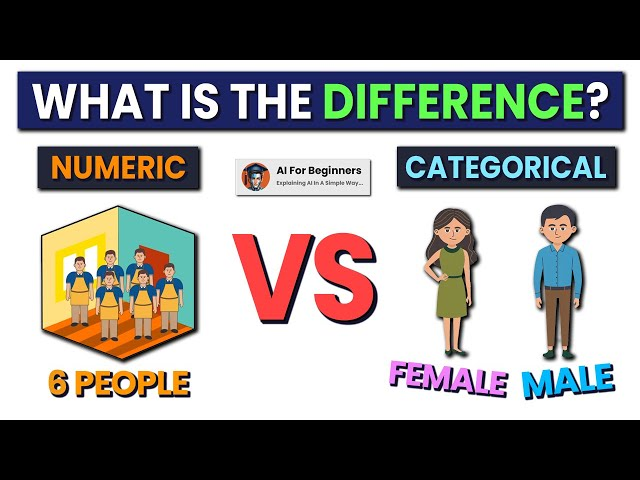

In [ ]:
# YOUR TURN: split the columns into numeric and categorical
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("NUMERIC:", num_cols)
print("CATEGORICAL:", cat_cols)

NUMERIC: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
CATEGORICAL: []


## One column at a time (Univariate)

**Numeric column** → histogram (shape), boxplot (median, spread, outliers), density
**Categorical column** → bar chart of counts (frequency, imbalance)

**Rule:** plot before you summarize. `describe()` hides shape.

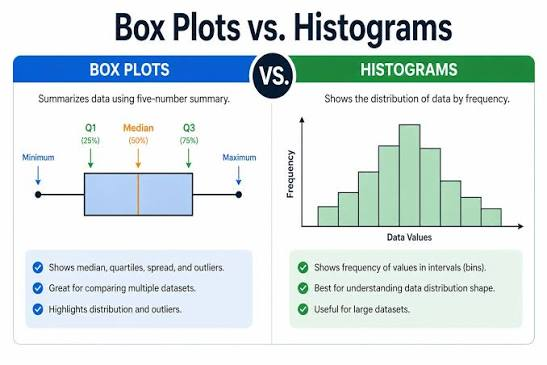

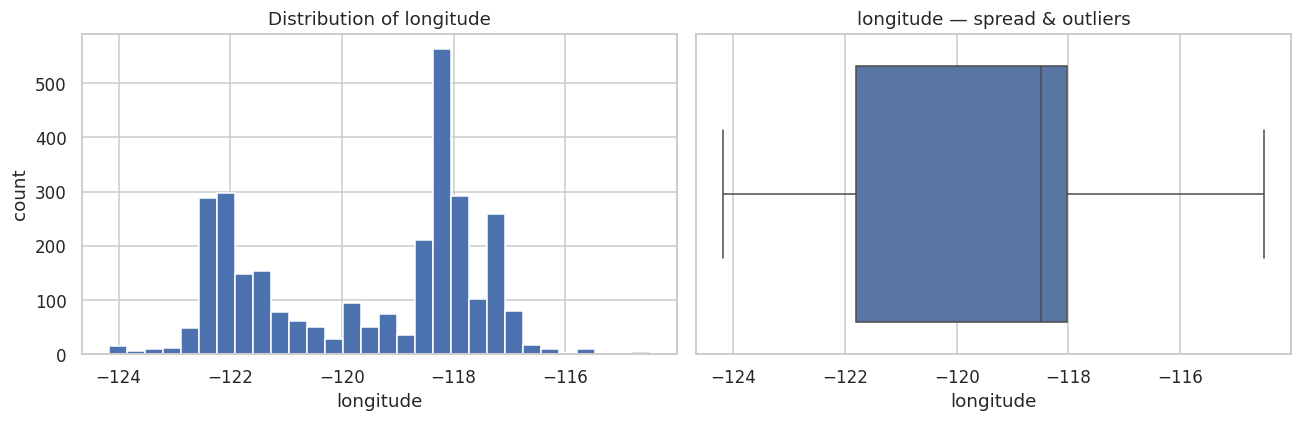

In [ ]:
#demo-> instructor's turn
col = num_cols[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[col].dropna(), bins=30)
axes[0].set_title(f"Distribution of {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("count")

sns.boxplot(x=df[col], ax=axes[1])
axes[1].set_title(f"{col} — spread & outliers")

plt.tight_layout()
plt.show()

In [ ]:
# YOUR TURN 1 — histogram
# 1. Pick a numeric column (not the one above).
# 2. Draw its histogram with bins=30.
# 3. Re-run with bins=5, then bins=100.
#
# Q: Which bin count "tells the truth"? What changes? What stays the same?

col = "___"
df[col].plot(kind="hist", bins=___)
plt.title(f"___")
plt.xlabel("___")
plt.show()

#PAY attention!
"Do you expect this to be symmetric, or skewed?" Then check — prediction beats description for retention.

Imbalanced categories are worth flagging now, because they break tests later.



In [ ]:
# YOUR TURN 2 — counts of a categorical column
# Sort by frequency so the biggest bar is on top.
# Hint: df[col].value_counts().plot(kind="barh")

col = "___"
df[col].value_counts().plot(kind="barh")
plt.title("___")
plt.xlabel("count")
plt.show()

## Two (or more) columns at once (Multivariate)

num ↔ num     → scatter (add a trend line)
num ↔ cat     → boxplot / violin / strip
cat ↔ cat     → grouped bars, or a heatmap of counts

Add a third variable with `hue=`. Patterns often only appear *within* groups.

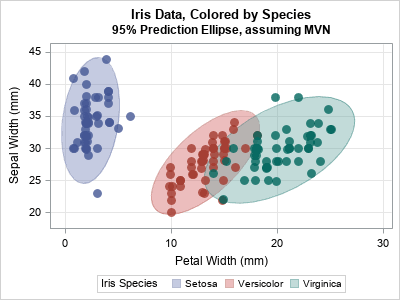

In [ ]:
x, y = num_cols[0], num_cols[1]

fig, ax = plt.subplots()
ax.scatter(df[x], df[y], alpha=0.6, s=25)
ax.set_xlabel(x)
ax.set_ylabel(y)
ax.set_title(f"{y} vs {x}")
plt.show()

In [ ]:
# Same scatter, split by a categorical variable
hue = cat_cols[0]
sns.scatterplot(data=df, x=x, y=y, hue=hue, alpha=0.7)
plt.title(f"{y} vs {x}, by {hue}")
plt.show()

#Your Turn!

In [ ]:
# YOUR TURN 3
# 1. Scatter two numeric columns you haven't used yet.
# 2. Add hue= for a categorical column. Does the pattern change per group?
# 3. Now make a boxplot of a numeric column split by a categorical one.

x, y = "___", "___"

sns.scatterplot(data=df, x=x, y=y, hue="___", alpha=0.7)
plt.show()

# sns.boxplot(data=df, x="___", y="___")
# plt.xticks(rotation=45)
# plt.show()

## What to report about a number (Despcriptive Stats)

- **Center:** mean, median
- **Spread:** std, IQR
- **Shape:** skew
- **Extremes:** min, max
- **Gaps:** missing count

`mean` far from `median` → skew → report the median.

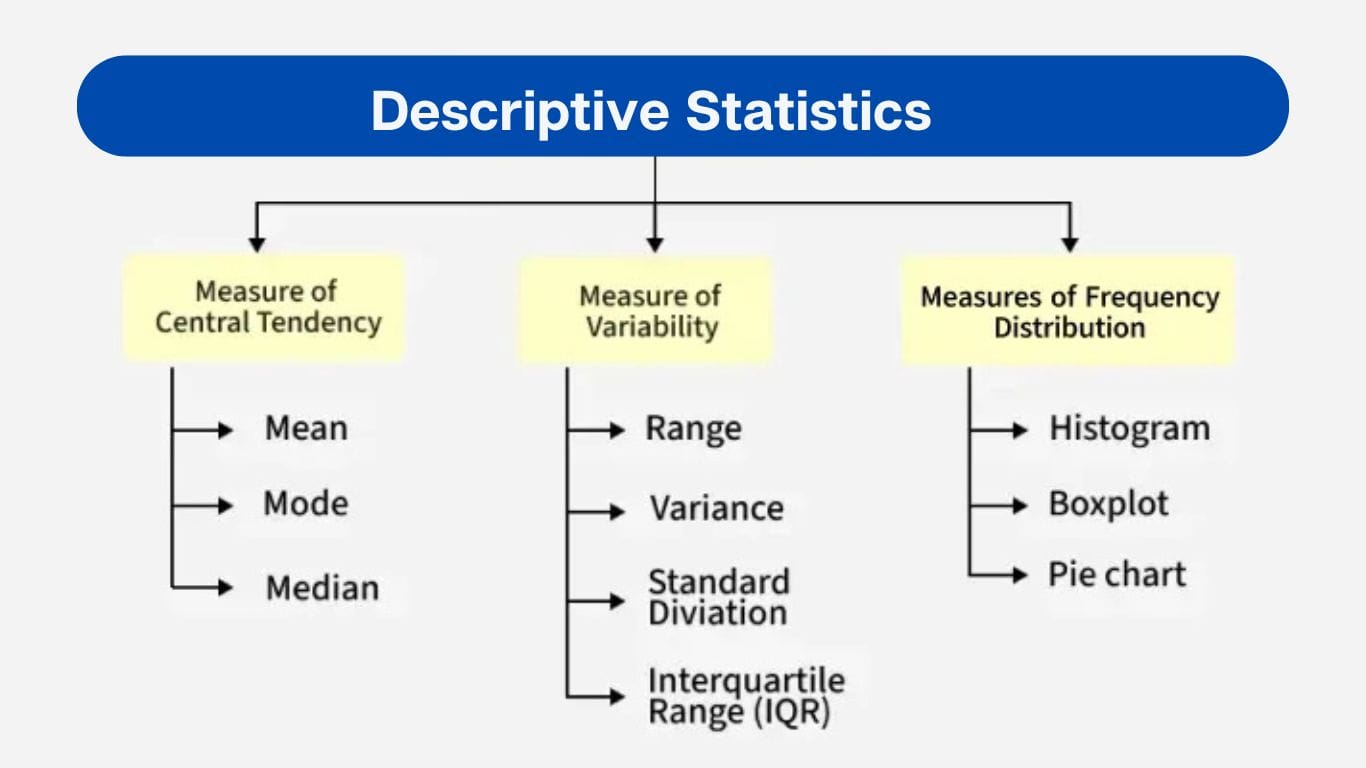

In [ ]:
df[num_cols].describe().T

In [ ]:
summary = pd.DataFrame({
    "mean":    df[num_cols].mean(),
    "median":  df[num_cols].median(),
    "std":     df[num_cols].std(),
    "skew":    df[num_cols].skew(),
    "missing": df[num_cols].isna().sum(),
})
summary["mean_minus_median"] = summary["mean"] - summary["median"]
summary.sort_values("skew", key=abs, ascending=False)

,mean,median,std,skew,missing,mean_minus_median
total_rooms,2599.578667,2106.00000,2155.593332,4.167637,0,493.578667
total_bedrooms,529.950667,437.00000,415.654368,3.863393,0,92.950667
households,489.912000,409.50000,365.422710,3.559753,0,80.412000
population,1402.798667,1155.00000,1030.543012,2.949671,0,247.798667
median_income,3.807272,3.48715,1.854512,1.698512,0,0.320122
median_house_value,205846.275000,177650.00000,113119.687470,0.989562,0,28196.275000
latitude,35.635390,34.27000,2.129670,0.459816,0,1.365390
longitude,-119.589200,-118.48500,1.994936,-0.297858,0,-1.104200
housing_median_age,28.845333,29.00000,12.555396,0.018513,0,-0.154667


# (Extra Credit) Correlation Heatmap

In [ ]:
corr = df[num_cols].corr(numeric_only=True)   # Pearson

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True)
plt.title("Correlation matrix")
plt.show()

#Your Turn

In [ ]:
# YOUR TURN 4
# 1. Find the strongest correlation in the matrix above (ignoring the diagonal).
# 2. Plot that pair as a scatter. Does the number match your eyes?
# 3. Re-run the heatmap with method="spearman". What moved?

# corr_s = df[num_cols].corr(method="spearman")

#(Extra Credit - Advanced) t-test
## Compare groups

- 2 groups, numeric outcome → **Welch t-test**
- 3+ groups, numeric outcome → **one-way ANOVA**
- 2 categorical variables → **chi-square**

Always: **group summary first, test second.**

In [ ]:
group_col = cat_cols[0]
outcome = num_cols[0]

df.groupby(group_col)[num_cols].agg(["mean", "median", "std", "count"])

In [ ]:
from scipy import stats
#t-test demo

levels = df[group_col].dropna().unique()
print("levels:", levels)

if len(levels) == 2:
    a = df.loc[df[group_col] == levels[0], outcome].dropna()
    b = df.loc[df[group_col] == levels[1], outcome].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)   # Welch
    print(f"{levels[0]}: mean={a.mean():.3f}, n={len(a)}")
    print(f"{levels[1]}: mean={b.mean():.3f}, n={len(b)}")
    print(f"t = {t:.3f}, p = {p:.4g}")
else:
    print("More than 2 levels — use ANOVA below.")

In [ ]:
# 3+ groups, numeric outcome
if len(levels) > 2:
    groups = [g[outcome].dropna() for _, g in df.groupby(group_col)]
    f, p = stats.f_oneway(*groups)
    print(f"F = {f:.3f}, p = {p:.4g}")

# 2 categorical variables
table = pd.crosstab(df[cat_cols[0]], df[cat_cols[1]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(table)
print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4g}")

In [ ]:
# YOUR TURN 5
# 1. Pick a categorical column and a numeric column.
# 2. Print the group summary (means + counts) FIRST.
# 3. Run the appropriate test.
# 4. Write one sentence in plain English: "The difference is / isn't
#    convincing because ___."

group_col = "___"
outcome = "___"
df.groupby(group_col)[outcome].agg(["mean", "median", "count"])


# YOUR TURN — Visuals & Stats
### Palmer Penguins

**Dataset:** `penguins` — body measurements for 344 penguins across 3 species
on 3 islands. Provided. Do not download your own for this one.

**Goal:** Apply everything from today to a dataset you didn't choose.
You'll be graded on *judgement*, not on how many plots you make.

**Deliverables:** A screenshot of your results (the one YOU think is the best and gives you the most information PLUS a couple of sentences in your own words how this was different from the datasets earlier.

**Rules**
- Write the code yourself. Copying a plot from the demo is fine; not understanding it isn't.
- Every figure needs a title and axis labels.
- Every written answer: 1–3 sentences, plain English, YOUR WORDS.
- If a result surprises you, say so. That's a good answer.

**Bonus: Do the advanced stats**

In [ ]:
import seaborn as sns

# Fixed dataset for this assignment — run as-is.
try:
    df = sns.load_dataset("penguins")
except Exception:
    # Offline fallback
    url = ("https://raw.githubusercontent.com/allisonhorst/"
           "palmerpenguins/main/inst/extdata/penguins.csv")
    df = pd.read_csv(url)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
